In [1]:
import jax
from jax import lax, Array
import jax.numpy as jnp
from jax.scipy.linalg import expm
jax.config.update('jax_enable_x64', True)
import numpy as np
from numpy.linalg import matrix_power
from scipy.stats import entropy, poisson
from scipy.optimize import minimize
from scipy.special import softmax, logsumexp
from itertools import product as iproduct
from time import perf_counter
from functools import partial

import os, sys, pathlib
os.environ["OPENBLAS_NUM_THREADS"] = "1"
_project_root = pathlib.Path.cwd().resolve()
sys.path.insert(0, str(_project_root.parents[0]))
sys.path.insert(0, str(_project_root.parents[1]))
from physics.markov import H, Hv, KL, KLv, get_traj
import physics.glauber as ising

GraphT = tuple[Array, Array, Array]

In [2]:
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.axes import Axes
from config import __mpl_paper_params__
mpl.rcParams.update(__mpl_paper_params__)

# Match the current paper's Ising line-plot style at final print size.
ISING_PAPER_RC_PARAMS = {
  "font.family": "serif",
  "mathtext.fontset": "cm",
  "font.size": 9,
  "axes.labelsize": 9,
  "axes.titlesize": 9,
  "axes.linewidth": 0.7,
  "xtick.labelsize": 8,
  "ytick.labelsize": 8,
  "xtick.direction": "in",
  "ytick.direction": "in",
  "xtick.top": True,
  "ytick.right": True,
  "xtick.major.size": 3.0,
  "ytick.major.size": 3.0,
  "xtick.minor.size": 1.8,
  "ytick.minor.size": 1.8,
  "xtick.major.width": 0.7,
  "ytick.major.width": 0.7,
  "xtick.minor.width": 0.6,
  "ytick.minor.width": 0.6,
  "text.usetex": True,
  "pdf.fonttype": 42,
  "ps.fonttype": 42,
  "svg.fonttype": "none",
}
mpl.rcParams.update(ISING_PAPER_RC_PARAMS)

Matplotlib is building the font cache; this may take a moment.


In [3]:
# ── Parameters ──────────────────────────────
# L      = 3
# shape  = (L, L)
N      = 9
n_states = 1 << N

J      = 0.2
h      = 0.0
T1, T2 = 1/3.0, 1/1.0
betas_nu = jnp.array([1/T1, 1/T2])
gammas_nu = jnp.array([1.0, 1.0])
dt = 1e-3

In [4]:
P0_reduced = jnp.zeros(N + 1)
P0_reduced = P0_reduced.at[N].set(1.0)

In [8]:
def add_heatmap(ax: Axes, heatmap, extent, *, cmap='magma'):
  return ax.imshow(
    heatmap,
    origin='lower',
    extent=extent,
    aspect='auto',
    cmap=cmap
  )

def render_heatmap(heatmap, Nsteps, extent, *, cmap='magma'):
  fig, ax = plt.subplots(1, 1, figsize=(8,6), squeeze=True)
  im = add_heatmap(ax, heatmap, extent)
  ax.set(xlabel=r"$h$", ylabel=r"$\beta$", title=fr"MMC at $N={Nsteps}$")
  fig.colorbar(im, ax=ax, label=r"$\mathcal{MC}_N$")
  plt.tight_layout()
  plt.show()

def compare_heatmaps(h1, h2, Nsteps, N, dt, h, J, beta1, extent, *, cmap='magma'):
  # fig, ax = plt.subplots(1, 1, figsize=(8,6), squeeze=True)
  fig, _axs = plt.subplots(1, 3, figsize=(20,6), squeeze=False)
  axs: list[Axes] = _axs.flatten().tolist()
  delta = np.asarray(h1 - h2)
  delta_absmax = float(np.max(np.abs(delta)))
  delta_norm = mcolors.TwoSlopeNorm(
    vmin=-(delta_absmax if delta_absmax > 0.0 else 1.0),
    vcenter=0.0,
    vmax=(delta_absmax if delta_absmax > 0.0 else 1.0),
  )

  im = add_heatmap(axs[0], h1, extent, cmap=cmap)
  axs[0].set(xlabel=r"$h$", ylabel=r"$\beta$", title=fr"MMC multi-reservoir; $\beta_1={beta1}$")
  fig.colorbar(im, ax=axs[0], label=r"$\mathcal{MC}_N$")

  im = add_heatmap(axs[1], h2, extent, cmap=cmap)
  axs[1].set(xlabel=r"$h$", ylabel=r"$\beta$", title=r"MMC single-reservoir")
  fig.colorbar(im, ax=axs[1], label=r"$\mathcal{MC}_N$")

  im = axs[2].imshow(
    delta,
    origin='lower',
    extent=extent,
    aspect='auto',
    cmap='RdBu_r',
    norm=delta_norm,
  )
  axs[2].set(xlabel=r"$h$", ylabel=r"$\beta$", title=r"$\Delta$MMC")
  fig.colorbar(im, ax=axs[2], label=r"$\Delta\mathcal{MC}_N$")
  fig.suptitle(fr"Minimal Periodic MMC for $N={Nsteps}$, $|\Lambda|={N}$, $dt={dt:.4f}$, $h={h}$, $J={J}$")
  plt.tight_layout()
  plt.show()
  fig.savefig(f"media/discrete_vs_continuous_N{Nsteps}_Lam{N}.pdf")


In [9]:
def make_sweep_curves_one_J_reduced(p0, N, gammas, h, dt):
  @partial(jax.jit, static_argnames=("N_max",))
  def sweep_one_J(J, beta_vals, N_max):
    def one(beta_2):
      betas = jnp.array([beta1, beta_2])
      return ising.mean_field_reduced_curves(p0, N, J, h, betas, gammas, dt, N_max)
    return lax.map(one, beta_vals)
  return sweep_one_J



In [10]:
# Parameter ranges
h_vals = jnp.linspace(0, 4, 100)
J_vals = jnp.linspace(-0.5, 0.5, 100)
beta_vals = jnp.linspace(0, 8, 100)
# BB, HH = jnp.meshgrid(beta_vals, h_vals, indexing="ij")
# params = jnp.stack([BB.ravel(), HH.ravel()], axis=1)
# Number of steps to include in the cumulative MMC
# N_plot = jnp.array([1, 2, 5, 10])
N_plot = jnp.array([10, 100, 1000, 10_000])
N_max = int(N_plot.max())
N_idx = np.asarray(N_plot - 1)


beta1 = 1.0 / T1

# extent = [h_vals[0], h_vals[-1], beta_vals[0], beta_vals[-1]]
# extent = [1, N_max + 1, beta_vals[0], beta_vals[-1]]
extent = [float(J_vals[0]), float(J_vals[-1]), float(beta_vals[0]), float(beta_vals[-1])]

sweep_J = make_sweep_curves_one_J_reduced(P0_reduced, N, gammas_nu, h, dt)

In [11]:

# shapes: (n_beta, n_J, N_max)
pmmc_cube = np.empty((len(beta_vals), len(J_vals), len(N_plot)), dtype=np.float32)
ep_cube   = np.empty((len(beta_vals), len(J_vals), len(N_plot)), dtype=np.float32)


for j, J in enumerate(np.asarray(J_vals)):
  pmmc_beta, ep_beta = sweep_J(J, beta_vals, N_max)
  pmmc_cube[:, j, :] = np.asarray(pmmc_beta)[:, N_idx]
  ep_cube[:, j, :]   = np.asarray(ep_beta)[:, N_idx]

ratio_cube = np.divide(
  pmmc_cube,
  ep_cube,
  out=np.full_like(pmmc_cube, np.nan),
  where=np.abs(ep_cube) > 1e-10,
)


In [20]:

def make_log_data_and_norm(data):
  data = np.asarray(data)

  positive = data[np.isfinite(data) & (data > 0)]
  if positive.size == 0:
    raise ValueError("Log-scaled data contains no positive values")

  masked = np.ma.masked_invalid(data)
  masked = np.ma.masked_less_equal(masked, 0.0)

  norm = mcolors.LogNorm(
      vmin=positive.min(),
      vmax=positive.max(),
  )
  return masked, norm

pmmc_log, pmmc_norm = make_log_data_and_norm(pmmc_cube)
ep_log, ep_norm = make_log_data_and_norm(ep_cube)

ratio_masked = np.ma.masked_invalid(ratio_cube)
# row_data = [pmmc_log, ep_log, ratio_masked]
# row_norms = [pmmc_norm, ep_norm, mcolors.Normalize(vmin=0.0, vmax=1.0)]
row_data = [ratio_masked]
row_norms = [mcolors.Normalize(vmin=0.0, vmax=1.0)]

J_grid = np.asarray(J_vals)
beta_grid = np.asarray(beta_vals)
T_values = np.asarray(N_plot, dtype=float) * float(dt)


# row_data = [pmmc_cube, ep_cube, ratio_cube]

# row_labels = [r"$\mathcal{M}_T$", r"$\Sigma_T$", r"$\mathcal{M}_T/\Sigma_T$"]
row_labels = [r"$\mathcal{M}_T/\Sigma_T$"]

# One common scale across all times within each row.
# This makes colors quantitatively comparable between columns.
# row_norms = [
#   mcolors.Normalize(
#     vmin=0.0,
#     vmax=max(float(np.nanmax(pmmc_cube)), 1e-15),
#   ),
#   mcolors.Normalize(
#     vmin=0.0,
#     vmax=max(float(np.nanmax(ep_cube)), 1e-15),
#   ),
#   mcolors.Normalize(vmin=0.0, vmax=1.0),
# ]

# Semantic colors match the line plots used in the paper.
C_MC, C_EP, C_RATIO = "#D55E00", "#0072B2", "#009E73"
mmc_cmap = mcolors.LinearSegmentedColormap.from_list(
  "mmc_seq", ["#FFF8F2", "#FDD0A2", C_MC, "#8C2D04"]
)
ep_cmap = mcolors.LinearSegmentedColormap.from_list(
  "ep_seq", ["#F7FBFF", "#BDD7E7", C_EP, "#084081"]
)
ratio_cmap = mcolors.LinearSegmentedColormap.from_list(
  "ratio_seq", ["#F7FCF5", "#BAE4B3", C_RATIO, "#005A32"]
)
# Undefined values remain distinct from valid low values.
for cmap in (mmc_cmap, ep_cmap, ratio_cmap):
  cmap.set_bad("#BDBDBD")

# row_cmaps = [mmc_cmap, ep_cmap, ratio_cmap]
row_cmaps = [ratio_cmap]

ncols = len(T_values)

ratio_finite = np.asarray(ratio_cube)[np.isfinite(ratio_cube)]
ratio_below = ratio_finite.size > 0 and ratio_finite.min() < 0.0
ratio_above = ratio_finite.size > 0 and ratio_finite.max() > 1.0
ratio_extend = (
  "both" if ratio_below and ratio_above
  else "min" if ratio_below
  else "max" if ratio_above
  else "neither"
)

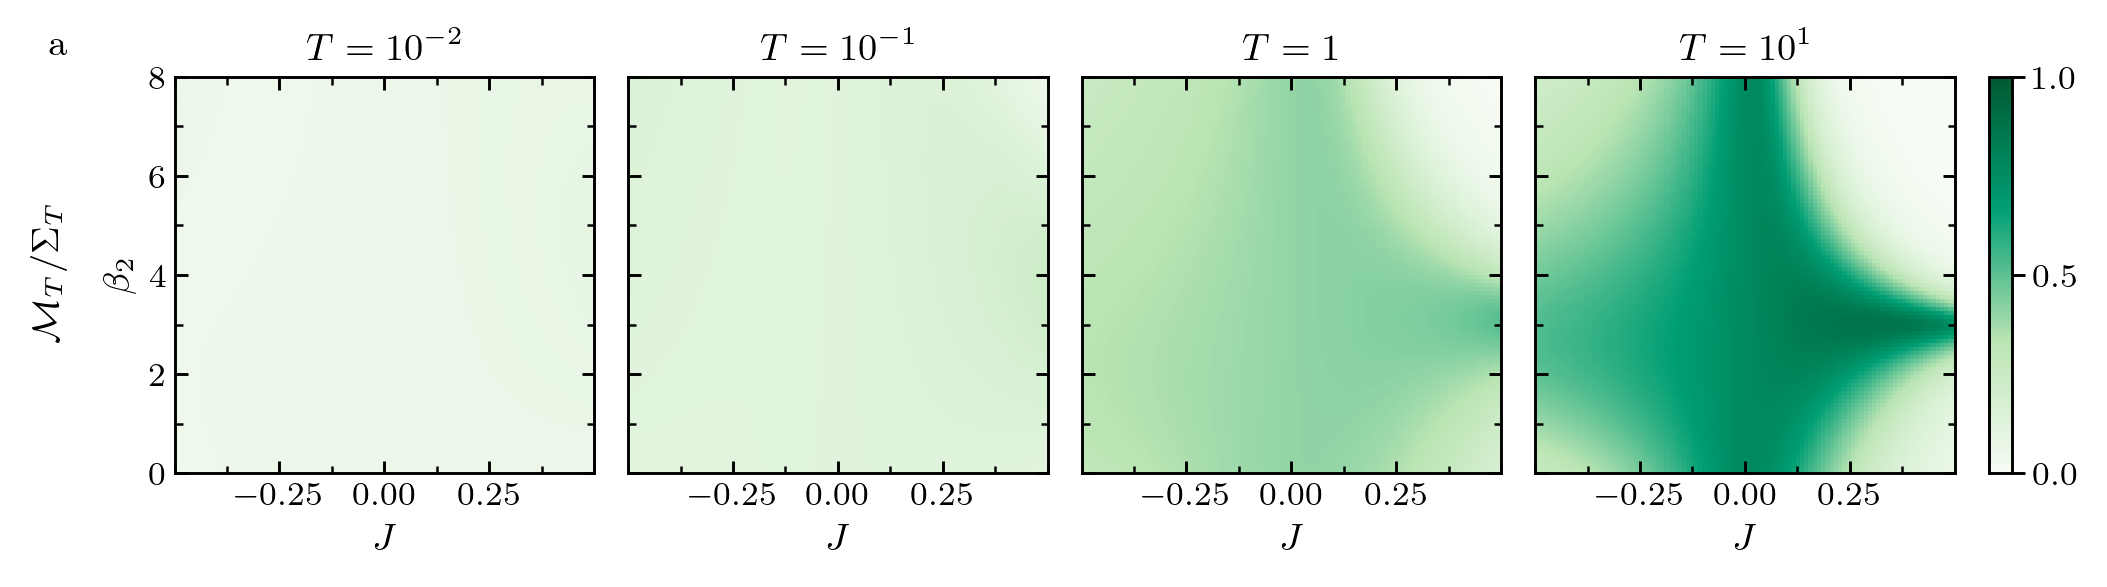

In [25]:
from matplotlib.ticker import AutoMinorLocator, LogFormatterMathtext, LogLocator, MaxNLocator

MM_PER_INCH = 25.4
figure_width = 183 / MM_PER_INCH  # Nature two-column width.
# figure_height = 135 / MM_PER_INCH
figure_height = 48 / MM_PER_INCH

def format_time_title(value):
  exponent = int(np.rint(np.log10(value)))
  if np.isclose(value, 10.0 ** exponent):
    return r"$T=1$" if exponent == 0 else rf"$T=10^{{{exponent}}}$"
  return rf"$T={value:g}$"

fig = plt.figure(figsize=(figure_width, figure_height))
grid = fig.add_gridspec(
  len(row_data),
  ncols + 1,
  width_ratios=[1] * ncols + [0.055],
  left=0.105,
  right=0.955,
  top=0.88,
  bottom=0.18,
  wspace=0.10,
  hspace=0.13,
)
axs = np.empty((len(row_data), ncols), dtype=object)
reference_ax = None
panel_labels = "abc"

for row, (data, label, norm, cmap) in enumerate(
    zip(row_data, row_labels, row_norms, row_cmaps)
):
  im = None
  for col, physical_time in enumerate(T_values):
    if reference_ax is None:
      ax = fig.add_subplot(grid[row, col])
      reference_ax = ax
    else:
      ax = fig.add_subplot(
        grid[row, col],
        sharex=reference_ax,
        sharey=reference_ax,
      )
    axs[row, col] = ax

    im = ax.pcolormesh(
      J_grid,
      beta_grid,
      data[:, :, col],
      shading="auto",
      cmap=cmap,
      norm=norm,
      rasterized=True,
    )
    ax.set_xlim(J_grid[0], J_grid[-1])
    ax.set_ylim(beta_grid[0], beta_grid[-1])
    # Keep decimal labels away from shared panel boundaries.
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4, prune="both"))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(which="both", direction="in", top=True, right=True, pad=2)

    if col == 0:
      ax.set_ylabel(r"$\beta_2$", labelpad=3)
    else:
      ax.tick_params(labelleft=False)

    if row == 0:
      ax.set_title(format_time_title(physical_time), pad=4)

    if row == len(row_data) - 1:
      ax.set_xlabel(r"$J$", labelpad=3)
    else:
      ax.tick_params(labelbottom=False)

  axs[row, 0].text(
    -0.30,
    1.035,
    panel_labels[row],
    transform=axs[row, 0].transAxes,
    fontsize=9,
    fontweight="bold",
    ha="left",
    va="bottom",
    clip_on=False,
  )
  axs[row, 0].text(
    -0.30,
    0.50,
    label,
    transform=axs[row, 0].transAxes,
    fontsize=9,
    rotation=90,
    ha="center",
    va="center",
    clip_on=False,
  )

  cbar = fig.colorbar(
    im,
    cax=fig.add_subplot(grid[row, -1]),
    extend=ratio_extend if row == 2 else "neither",
  )
  cbar.ax.yaxis.set_ticks_position("right")
  cbar.ax.tick_params(which="major", direction="out", length=3, width=0.7, pad=2)
  cbar.ax.tick_params(which="minor", direction="out", length=1.8, width=0.6)
  cbar.outline.set_linewidth(0.7)
  if isinstance(norm, mcolors.LogNorm):
    cbar.locator = LogLocator(base=10, numticks=5)
    cbar.formatter = LogFormatterMathtext(base=10)
  else:
    cbar.set_ticks([0.0, 0.5, 1.0])
    cbar.ax.yaxis.set_minor_locator(AutoMinorLocator(2))
  cbar.update_ticks()

fig.align_ylabels(axs[:, 0])
plt.show()



# for col, (n, idx) in enumerate(zip(np.asarray(N_plot), N_idx)):
#   im = add_heatmap(axs[0, col], pmmc_cube[:, :, col], extent, cmap="magma")
#   axs[0, col].set_title(rf"$\mathcal{{M}}_{{{n}}}$")
#   axs[0, col].set(xlabel=r"$J$", ylabel=r"$\beta_2$")
#   fig.colorbar(im, ax=axs[0, col], label=r"$\mathcal{MC}_N$")

#   im = add_heatmap(axs[1, col], ep_cube[:, :, col], extent, cmap="magma")
#   axs[1, col].set_title(rf"$\Sigma_{{{n}}}$")
#   axs[1, col].set(xlabel=r"$J$", ylabel=r"$\beta_2$")
#   fig.colorbar(im, ax=axs[1, col], label=r"$\mathcal{MC}_N$")

#   im = add_heatmap(axs[2, col], ratio_cube[:, :, col], extent, cmap="viridis")
#   axs[2, col].set_title(rf"$\mathcal{{M}}_{{{n}}}/\Sigma_{{{n}}}$")
#   axs[2, col].set(xlabel=r"$J$", ylabel=r"$\beta_2$")
#   fig.colorbar(im, ax=axs[2, col], label=r"$\mathcal{MC}_N$")

In [26]:
output_dir = pathlib.Path("media")
output_dir.mkdir(parents=True, exist_ok=True)
output_stem = output_dir / f"mean_field_continuous_time_heatmaps_{N}_{N_max}_one_row"

fig.savefig(
  output_stem.with_suffix(".pdf"),
  dpi=600,
  facecolor="white",
  metadata={"Title": "Mean-field continuous-time heatmaps", "Creator": "Matplotlib"},
)
fig.savefig(
  output_stem.with_suffix(".svg"),
  dpi=600,
  facecolor="white",
  metadata={"Title": "Mean-field continuous-time heatmaps"},
)
fig.savefig(
  output_stem.with_suffix(".png"),
  dpi=600,
  facecolor="white",
  metadata={"Title": "Mean-field continuous-time heatmaps"},
)